In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('../dataset/iris.data.csv', header=None)  # Load the Iris dataset

# voglio sostituire le etichette di testo con numeri
df[4] = df[4].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


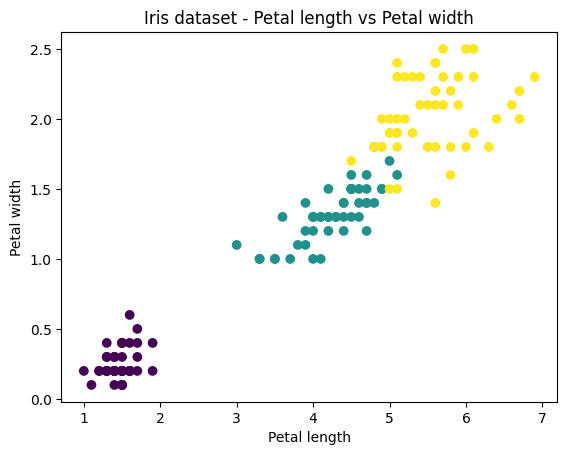

In [8]:
# voglio fare un scatter plot delle prime due caratteristiche colorando i punti in base alla classe
plt.scatter(df[2], df[3], c=df[4])
plt.xlabel('Petal length')
plt.ylabel('Petal width')
plt.title('Iris dataset - Petal length vs Petal width')
plt.show()

In [9]:
X = df.drop([4], axis='columns')
y = df[4]

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Input

accuracies = []
for n_layer in [2,3,4,5]:
    l = [Input(shape=(X_train.shape[1],))]
    for _ in range(n_layer):
     l.append(Dense(10, activation="relu"))
    l.append(Dense(3, activation="softmax"))


    model = Sequential(l)
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)
    y_pred = model.predict(X_test)
    y_pred = [np.argmax(p) for p in y_pred]
    a = accuracy_score(y_test, y_pred)
    accuracies.append(a)

print(accuracies)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 1.1268 - val_loss: 1.1182
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.1220 - val_loss: 1.1147
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.1176 - val_loss: 1.1113
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.1135 - val_loss: 1.1080
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.1097 - val_loss: 1.1050
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.1062 - val_loss: 1.1026
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.1032 - val_loss: 1.1004
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.1004 - val_loss: 1.0984
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.0977 - val_loss: 1.0967
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.0951 - val_loss: 1.0954
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.0928 - val_loss: 1.0942
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.0908 - val_lo

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 1.0595 - val_loss: 1.0690
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0394 - val_loss: 1.0528
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0200 - val_loss: 1.0366
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.0016 - val_loss: 1.0214
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9841 - val_loss: 1.0065
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9681 - val_loss: 0.9931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9523 - val_loss: 0.9803
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.9363 - val_loss: 0.9672
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9221 - val_loss: 0.9550
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9076 - val_loss: 0.9429
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8938 - val_loss: 0.9307
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8802 - val_lo

In [12]:
y_pred = model.predict(X_test)
y_pred = [np.argmax(p) for p in y_pred]
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[[11  0  0]
 [ 0  8  2]
 [ 0  0  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.80      0.89        10
           2       0.82      1.00      0.90         9

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.95      0.93      0.93        30

